# Credit Card customers
## Predict Churning customers

In [2]:
# importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

In [3]:
# reading the csv file
credit_df = pd.read_csv('./BankChurners.csv')
credit_df.sample(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
5867,769892058,Existing Customer,40,M,3,Uneducated,Single,$80K - $120K,Blue,34,...,9124.0,2126,6998.0,0.449,4564,65,0.548,0.233,0.000121,0.99988
2431,720424608,Existing Customer,56,F,1,Unknown,Married,Unknown,Blue,36,...,24073.0,1084,22989.0,0.847,1341,37,1.176,0.045,0.000186,0.99981
1947,709974108,Existing Customer,35,F,1,Graduate,Single,Less than $40K,Blue,23,...,2640.0,1051,1589.0,0.833,3116,80,0.600,0.398,0.000284,0.99972
9442,714682233,Existing Customer,48,M,3,Graduate,Married,$80K - $120K,Blue,43,...,9959.0,0,9959.0,0.751,14948,125,0.866,0.000,0.000136,0.99986
7278,708784083,Existing Customer,47,F,3,Uneducated,Single,Less than $40K,Blue,36,...,2723.0,1588,1135.0,0.852,4307,83,0.844,0.583,0.000073,0.99993


In [4]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [5]:
# deleting the last to columns as mentioned on the kaggle website for better working
credit_df.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], inplace = True , axis = 1)

In [6]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [7]:
round(credit_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,36903783.45,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.633000e+01,8.02,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.350000e+00,1.30,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.593000e+01,7.99,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.810000e+00,1.55,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.340000e+00,1.01,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.460000e+00,1.11,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631950e+03,9088.78,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162810e+03,814.99,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9090.69,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [8]:
# checking for null values
credit_df.isna().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

* OBSERVATION : NO NULL VALUES IN THE DATASET

In [9]:
# the colums client num is not required
credit_df.drop('CLIENTNUM',inplace=True, axis = 1)

In [10]:
# finding the unique values in categorical columns
categorical_cols = credit_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical_cols :
    unique = credit_df[cols].value_counts()
    print(f"COLUMN : {cols}")
    print(f"Values : {unique}")
    print("\n")

COLUMN : Attrition_Flag
Values : Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


COLUMN : Gender
Values : Gender
F    5358
M    4769
Name: count, dtype: int64


COLUMN : Education_Level
Values : Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64


COLUMN : Marital_Status
Values : Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64


COLUMN : Income_Category
Values : Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64


COLUMN : Card_Category
Values : Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64




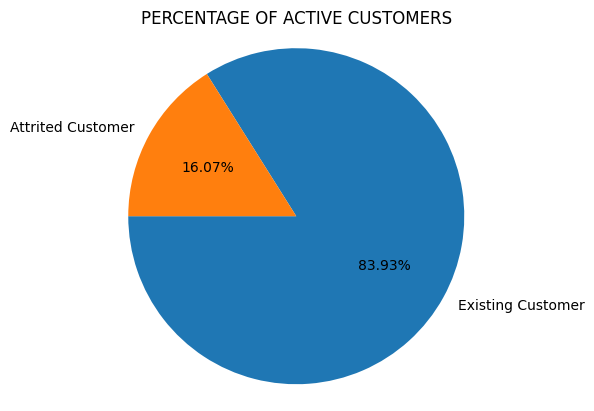

In [11]:
attrition_names = credit_df.Attrition_Flag.value_counts().index

attrition_val = credit_df.Attrition_Flag.value_counts().values

plt.Figure(figsize=(6,6))
plt.title("PERCENTAGE OF ACTIVE CUSTOMERS")
plt.pie(
   attrition_val,
   labels = attrition_names,
   startangle= 180,
   autopct='%1.2f%%'
)
plt.axis('Equal')
plt.show()

# MAPPING

In [12]:
credit_df['Gender'] = credit_df['Gender'].map({'M': 0, 'F': 1})
credit_df['Attrition_Flag'] = credit_df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

In [13]:
# checking the new columns
credit_df.Gender

0        0
1        1
2        0
3        1
4        0
        ..
10122    0
10123    0
10124    1
10125    0
10126    1
Name: Gender, Length: 10127, dtype: int64

In [14]:
credit_df.Attrition_Flag

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    1
10126    1
Name: Attrition_Flag, Length: 10127, dtype: int64

* OBSERVATION : WE CAN ALSO MAP THE CARD CATEGORY

In [15]:
credit_df.Card_Category.unique()

array(['Blue', 'Gold', 'Silver', 'Platinum'], dtype=object)

In [16]:
mapping_code = {'Blue' : 0, 'Gold' : 1, 'Silver' : 2, 'Platinum' : 3}
credit_df['Card_Category'] = credit_df.Card_Category.map(mapping_code)

In [17]:
credit_df.Card_Category

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    0
10124    0
10125    0
10126    2
Name: Card_Category, Length: 10127, dtype: int64

# SPLITING THE DATASET

In [18]:
X = credit_df.drop('Attrition_Flag',axis = 1)
Y = credit_df['Attrition_Flag']

print(X.shape)
print(Y.shape)

(10127, 19)
(10127,)


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.25)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(7595, 19)
(2532, 19)
(7595,)
(2532,)


# ENCODING THE OTHER COLUMNS

In [20]:
cat_cols = X_train.select_dtypes('object').columns.tolist()

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoder.fit(X_train[cat_cols])

encoded_cols = list(encoder.get_feature_names_out(cat_cols))

X_train[encoded_cols] = encoder.transform(X_train[cat_cols])
X_test[encoded_cols] = encoder.transform(X_test[cat_cols])

X_train.drop(columns = cat_cols, inplace = True)
X_test.drop(columns = cat_cols, inplace = True)

# SCALING

In [21]:
credit_df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [22]:
numeric_cols = ['Customer_Age','Dependent_count','Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon','Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt',
'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train = scaler.transform(X_train[numeric_cols])
X_test = scaler.transform(X_test[numeric_cols])

In [23]:
Y_train.value_counts()

Attrition_Flag
0    6387
1    1208
Name: count, dtype: int64

* the number of 0s is more than 1s so we should use SMOTE here because it help us to rule that out and bring the number of 1s and 0s to equal level

In [25]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE : {Y_train.value_counts().to_dict()}")

smote = SMOTE(random_state = 42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train,Y_train)

print(f"After SMOTE : {Y_train_resampled.value_counts().to_dict()}")

Before SMOTE : {0: 6387, 1: 1208}
After SMOTE : {0: 6387, 1: 6387}


* CREATING A FUNCTION TO TRAIN MODELS

In [31]:
from sklearn.metrics import classification_report, roc_auc_score,ConfusionMatrixDisplay

def evalute(model,name) :
    model.fit(X_train_resampled,Y_train_resampled)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]

    print(f"Model : {name}")
    print(f"ROC-AUC: {roc_auc_score(Y_test, proba):.4f}")
    print(classification_report(Y_test, preds))
    ConfusionMatrixDisplay.from_predictions(Y_test,preds)
    plt.title(f"{name} Confusion Matrix")
    plt.show()




Model : Logistic Regression
ROC-AUC: 0.9150
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2113
           1       0.52      0.83      0.64       419

    accuracy                           0.84      2532
   macro avg       0.74      0.84      0.77      2532
weighted avg       0.89      0.84      0.86      2532



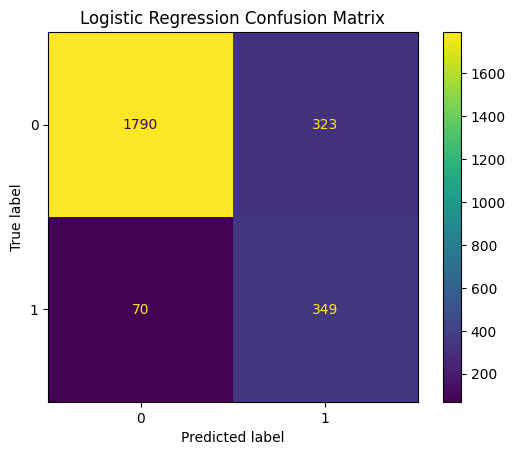

In [32]:
from sklearn.linear_model import LogisticRegression

evalute(LogisticRegression(random_state=42),'Logistic Regression')

# TRAINING A RANDOM FOREST MODEL FROM SCRATCH 

* because random forest does not need scaled numeric value

In [33]:
X = credit_df.drop('Attrition_Flag',axis =1 )
Y = credit_df['Attrition_Flag']

print(X.shape)
print(Y.shape)

(10127, 19)
(10127,)


In [40]:
categorical_cols = X.select_dtypes(include = 'object').columns.tolist()

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X[categorical_cols])

encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
X[encoded_cols] = encoder.transform(X[categorical_cols])

X.drop(columns = categorical_cols,inplace = True)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        max_depth=5,
        n_estimators=100
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, Y, cv=skf, scoring='f1')

print("F1 Scores:", scores)
print("Average F1:", scores.mean())

F1 Scores: [0.74424899 0.76693767 0.7639485  0.74861878 0.75247525]
Average F1: 0.7552458368801862


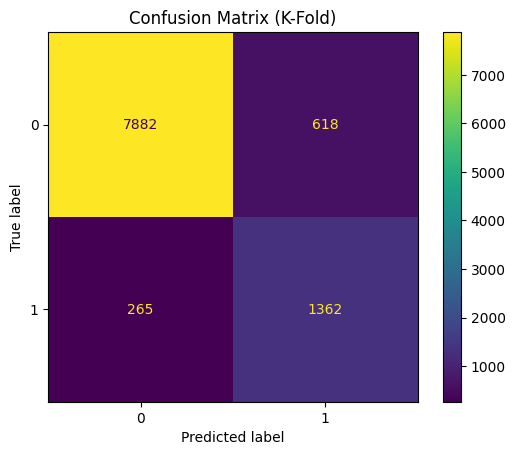

In [42]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(pipeline, X, Y, cv=skf)

cm = confusion_matrix(Y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (K-Fold)")
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(Y, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      8500
           1       0.69      0.84      0.76      1627

    accuracy                           0.91     10127
   macro avg       0.83      0.88      0.85     10127
weighted avg       0.92      0.91      0.92     10127

